In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from dowhy import CausalModel
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import graphviz
from IPython.display import display
import importlib, tests
importlib.reload(tests)


/Users/mkhan04/Desktop/ci4security/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'tests' from '/Users/mkhan04/Desktop/ci4security/causal_analysis_cryptoguard/tests.py'>

In [2]:
df = pd.read_csv("alerts_with_category_and_apk_size_updated_cryptoguard.csv")
print("Original rows:", len(df))

df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()
print("After removing obfuscated:", len(df))

df["verdict"] = df["verdict"].astype(int)
df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
print(df["is_third_party"].value_counts())
df["lib_category"] = df["code_location"].apply(
    lambda x: x if x != "developer_written" else "source"
)

df["developer_written_and_third_party"] = (
    (df["code_location"] == "developer_written") | (df["is_third_party"] == 1)
).astype(int)


df_all = df.copy()
df_all["combined"] = 1
df_developer_written = df[df["code_location"] == "developer_written"].copy()
df_developer_written["combined"] = 0
df_final = pd.concat([df_all, df_developer_written], ignore_index=True)
df = df_final.copy()


print("\nVerdict value counts:")
print(df["verdict"].value_counts())
print("\nCode location value counts:")
print(df["code_location"].value_counts())


Original rows: 15287
After removing obfuscated: 15268
is_third_party
1    13943
0     1325
Name: count, dtype: int64

Verdict value counts:
verdict
0    8560
1    8033
Name: count, dtype: int64

Code location value counts:
code_location
Android              6028
others               4112
Utilities            3234
developer_written    2650
SocialMedia           475
Analytics              53
Cloud                  41
Name: count, dtype: int64


In [3]:
df["apk_category"].value_counts()

apk_category
<100         2112
100k-500k    2018
500k-1M      1972
>5M          1459
100-500      1459
1k-5k        1401
500-1k       1342
5k-10k       1256
10k-50k      1223
50k-100k     1189
1M-5M        1162
Name: count, dtype: int64

In [4]:
df.columns

Index(['alert_description', 'verdict', 'artifact_location', 'app_package_name',
       'version_code', 'apk_category', 'sast_tool_name', 'code_location',
       '3rd_party_library_name', 'apk_size', 'is_third_party', 'lib_category',
       'developer_written_and_third_party', 'combined'],
      dtype='object')

In [5]:
scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])
print("\napk_size_scaled summary:")
print(df["apk_size_scaled"].describe())



apk_size_scaled summary:
count    16593.000000
mean         0.463681
std          1.464817
min         -0.846879
25%         -0.354017
50%          0.000000
75%          0.645983
max          9.872871
Name: apk_size_scaled, dtype: float64


In [6]:
category_order = [
    '<100','100-500','500-1k','1k-5k','5k-10k','10k-50k',
    '50k-100k','100k-500k','500k-1M','1M-5M','>5M'
]
ord_map = {c: i for i, c in enumerate(category_order)}

df["app_popularity_encoded"] = df["apk_category"].map(ord_map)

df = df.dropna(subset=["app_popularity_encoded"]).copy()
df["app_popularity_encoded"] = df["app_popularity_encoded"].astype(int)

print("\nApp popularity encoded value counts:")
print(df["app_popularity_encoded"].value_counts().sort_index())




App popularity encoded value counts:
app_popularity_encoded
0     2112
1     1459
2     1342
3     1401
4     1256
5     1223
6     1189
7     2018
8     1972
9     1162
10    1459
Name: count, dtype: int64


In [7]:
# cols = ["apk_size_scaled", "app_popularity_encoded", "verdict", "is_third_party"]

# g = sns.PairGrid(df[cols], hue="is_third_party", diag_sharey=False)
# g.map_diag(sns.histplot)
# g.map_offdiag(sns.scatterplot)
# g.add_legend()
# plt.show()

In [8]:
n_bootstraps = 200
boot_means = {
    "apk_size_scaled": [],
    "verdict": [],
    "is_third_party": [],
}

for _ in range(n_bootstraps):
    boot_sample = df.sample(frac=1, replace=True)
    boot_means["apk_size_scaled"].append(boot_sample["apk_size_scaled"].mean())
    boot_means["verdict"].append(boot_sample["verdict"].mean())
    boot_means["is_third_party"].append(boot_sample["is_third_party"].mean())

summary = {}
for col, values in boot_means.items():
    values = np.array(values)
    summary[col] = {
        "mean": np.mean(values),
        "std": np.std(values, ddof=1),
        "95% CI lower": np.percentile(values, 2.5),
        "95% CI upper": np.percentile(values, 97.5),
    }

summary_df = pd.DataFrame(summary).T
print("\nBootstrap summary (descriptive stats):")
print(summary_df)




Bootstrap summary (descriptive stats):
                     mean       std  95% CI lower  95% CI upper
apk_size_scaled  0.463545  0.011006      0.443421      0.486562
verdict          0.483994  0.003741      0.476103      0.490516
is_third_party   0.840253  0.002850      0.834744      0.846140


In [9]:
# cols = ["apk_size_scaled", "app_popularity_encoded", "verdict", "is_third_party"]

# g = sns.PairGrid(df[cols], hue="is_third_party", diag_sharey=False)
# g.map_diag(sns.histplot)
# g.map_offdiag(sns.scatterplot)
# g.add_legend()
# plt.show()

In [10]:
# plt.figure(figsize=(8,5))
# sns.histplot(boot_means["apk_size_scaled"], kde=True)
# plt.title("Bootstrap Distribution of APK Size Mean")
# plt.xlabel("Mean APK Size (Scaled)")
# plt.ylabel("Frequency")
# plt.show()

In [11]:
# causal_graph = """
# digraph {
#     is_third_party -> verdict;
#     apk_size_scaled -> is_third_party;
#     apk_size_scaled -> verdict;
#     app_popularity_encoded -> is_third_party;
#     app_popularity_encoded -> verdict;
# }
# """

causal_graph_2 = """
digraph {
    combined -> verdict;
    apk_size_scaled -> combined;
    apk_size_scaled -> verdict;
    app_popularity_encoded -> combined;
    app_popularity_encoded -> verdict;
    app_popularity_encoded -> apk_size_scaled;
}
"""

# causal_graph_only_size = """
# digraph {
#     apk_size_scaled -> is_third_party;
#     apk_size_scaled -> verdict;
#     is_third_party -> verdict;
# }
# """

# causal_graph_only_app_popularity = """
# digraph {
#     is_third_party -> verdict;
#     app_popularity_encoded -> is_third_party;
#     app_popularity_encoded -> verdict;
# }
# """

# causal_graph_after_correlation_test = """
# digraph {
#     is_third_party -> verdict;
#     apk_size_scaled -> is_third_party;
#     app_popularity_encoded -> is_third_party;
#     app_popularity_encoded -> verdict;
#     app_popularity_encoded -> apk_size_scaled;
# }
# """


In [12]:
def all_correlation_tests():
    tests.kruskal_test_continuous_by_groups(df, "app_popularity_encoded", "apk_size_scaled")

    tests.logistic_regression_numeric_to_binary(df, "app_popularity_encoded", "verdict")
    tests.chi_square_test_cat_to_binary(df, "app_popularity_encoded", "verdict")

    tests.logistic_regression_numeric_to_binary(df, "app_popularity_encoded", "combined")
    tests.chi_square_test_cat_to_binary(df, "app_popularity_encoded", "combined")

    tests.logistic_regression_binary_to_binary(df, "combined", "verdict")

    tests.logistic_regression_numeric_to_binary(df, "apk_size_scaled", "combined")
    tests.mann_whitney_test(df, "apk_size_scaled", "combined")

    tests.logistic_regression_numeric_to_binary(df, "apk_size_scaled", "verdict")
    tests.mann_whitney_test(df, "apk_size_scaled", "verdict")

    tests.mann_whitney_test(df, "app_popularity_encoded", "combined")
    tests.correlation_test_treatment_to_outcome(df)



In [13]:
all_correlation_tests()


app_popularity_encoded -> apk_size_scaled (Kruskal–Wallis)
H = 1226.190, p = 0.0000
Edge is not rejected (p < 0.05)

app_popularity_encoded -> verdict (Logistic regression)
coef = 0.0367, p = 0.0000
Edge is not rejected (p < 0.05)

app_popularity_encoded -> verdict (Chi-square)
chi2 = 176.599, dof = 10, p = 0.0000
Edge is not rejected (p < 0.05)

app_popularity_encoded -> combined (Logistic regression)
coef = 0.0362, p = 0.0000
Edge is not rejected (p < 0.05)

app_popularity_encoded -> combined (Chi-square)
chi2 = 241.030, dof = 10, p = 0.0000
Edge is not rejected (p < 0.05)

combined -> verdict (Logistic regression)
coef = -0.1134, p = 0.0479
Edge is not rejected (p < 0.05)

apk_size_scaled -> combined (Logistic regression)
coef = 0.1467, p = 0.0000
Edge is not rejected (p < 0.05)

apk_size_scaled -> combined (Mann–Whitney U)
U = 8738053.000, p = 0.0000
Edge is not rejected (p < 0.05)

apk_size_scaled -> verdict (Logistic regression)
coef = -0.0613, p = 0.0000
Edge is not rejected (p

In [14]:
# model = CausalModel(
#     data=df,
#     treatment="is_third_party",
#     outcome="verdict",
#     graph=causal_graph.replace("\n", " "),
#     common_causes=["apk_size_scaled", "app_popularity_encoded"],
# )

model_2 = CausalModel(
    data=df,
    treatment="combined",
    outcome="verdict",
    graph=causal_graph_2.replace("\n", " "),
    common_causes=["apk_size_scaled", "app_popularity_encoded"],
)

# model_only_size = CausalModel(
#     data=df,
#     treatment="is_third_party",
#     outcome="verdict",
#     graph=causal_graph_only_size.replace("\n", " "),
#     common_causes=["apk_size_scaled"],
# )

# model_only_app_popularity = CausalModel(
#     data=df,
#     treatment="is_third_party" ,
#     outcome="verdict",
#     graph=causal_graph_only_app_popularity.replace("\n", " "),
#     common_causes=["app_popularity_encoded"],
# )

# model_after_correlation_test = CausalModel(
#     data=df,
#     treatment="is_third_party",
#     outcome="verdict",
#     graph=causal_graph_after_correlation_test.replace("\n", " "),
#     common_causes=["app_popularity_encoded"],
# )


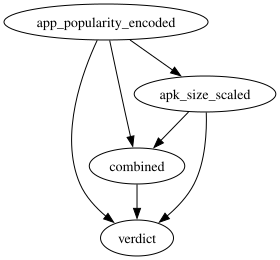

In [15]:

# g5 = graphviz.Source(causal_graph_after_correlation_test)
g2 = graphviz.Source(causal_graph_2)
# display(g5)
display(g2)

In [16]:
# identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
identified_estimand_2 = model_2.identify_effect(proceed_when_unidentifiable=True)
# identified_estimand_only_size = model_only_size.identify_effect(proceed_when_unidentifiable=True)
# identified_estimand_only_app_popularity = model_only_app_popularity.identify_effect(proceed_when_unidentifiable=True)
# identified_estimand_after_correlation_test = model_after_correlation_test.identify_effect(
#     proceed_when_unidentifiable=True
# )

print("\n------- Identified estimands -------")
print(identified_estimand_2)
# print(identified_estimand_after_correlation_test)



------- Identified estimands -------
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                        
───────────(E[verdict|apk_size_scaled,app_popularity_encoded])
d[combined]                                                   
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,apk_size_scaled,app_popularity_encoded,U) = P(verdict|combined,apk_size_scaled,app_popularity_encoded)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                                        
───────────(E[verdict|apk_size_scaled,app_popularity_encoded])
d[combined]                                                   
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict 

In [17]:
# estimate = model.estimate_effect(
#     identified_estimand,
#     method_name="backdoor.propensity_score_matching",
#     target_units="ate",
#     test_significance=True,
#     confidence_intervals='bootstrap',
#     method_params={
#         "num_simulations": 300,
#         "sample_size_fraction": 1.0,
#         "confidence_level": 0.95,
#     },
# )

estimate_2 = model_2.estimate_effect(
    identified_estimand_2,
    method_name="backdoor.propensity_score_matching",
    target_units="ate",
    test_significance=True,
   confidence_intervals='bootstrap',
    method_params={
        "num_simulations": 300,
        "sample_size_fraction": 1.0,
        "confidence_level": 0.95,
    },
)

# estimate_only_size = model_only_size.estimate_effect(
#     identified_estimand_only_size,
#     method_name="backdoor.propensity_score_matching",
#     target_units="ate",
#     test_significance=True,
#     confidence_intervals='bootstrap',
#     method_params={
#         "num_simulations": 300,
#         "sample_size_fraction": 1.0,
#         "confidence_level": 0.95,
#     },
# )

# estimate_only_app_popularity = model_only_app_popularity.estimate_effect(
#     identified_estimand_only_app_popularity,
#     method_name="backdoor.propensity_score_matching",
#     target_units="ate",
#     test_significance=True,
#     confidence_intervals='bootstrap',
#     method_params={
#         "num_simulations": 300,
#         "sample_size_fraction": 1.0,
#         "confidence_level": 0.95,
#     },
# )

# estimate_after_correlation_test = model_after_correlation_test.estimate_effect(
#     identified_estimand_after_correlation_test,
#     method_name="backdoor.propensity_score_matching",
#     target_units="ate",
#     test_significance=True,
#     confidence_intervals='bootstrap',
#     method_params={
#         "num_simulations": 300,
#         "sample_size_fraction": 1.0,
#         "confidence_level": 0.95,
#     },

# )

print("\n------- Causal effect estimates -------")
# print(estate, "\n", "-------" * 10)
print(estimate_2, "\n", "-------" * 10)
# print(estimate_only_size, "\n", "-------" * 10)
# print(estimate_only_app_popularity, "\n", "-------" * 10)
# print(estimate_after_correlation_test)


------- Causal effect estimates -------
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                        
───────────(E[verdict|apk_size_scaled,app_popularity_encoded])
d[combined]                                                   
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,apk_size_scaled,app_popularity_encoded,U) = P(verdict|combined,apk_size_scaled,app_popularity_encoded)

## Realized estimand
b: verdict~combined+apk_size_scaled+app_popularity_encoded
Target units: ate

## Estimate
Mean value: 0.029952389561863437
p-value: 0.25
95.0% confidence interval: (np.float64(-0.014765262460073526), np.float64(0.1070933526185741))
 
 ----------------------------------------------------------------------


In [18]:
estimate_2.interpret(method_name="textual_effect_interpreter")

Increasing the treatment variable(s) [combined] from 0 to 1 causes an increase of 0.029952389561863437 in the expected value of the outcome [['verdict']], over the data distribution/population represented by the dataset.


In [19]:
refutation_methods = [
    "random_common_cause",
    "placebo_treatment_refuter",
    "data_subset_refuter",
]

# # print("\n", "----" * 15, "Both size and app_popularity as confounders (graph 1)", "----" * 15)
# for method in refutation_methods:
#     ref = model.refute_estimate(identified_estimand, estimate, method_name=method)
#     # print(f"\nRefuter: {method}\n", ref)

# print("\n", "----" * 15, "Both size and app_popularity as confounders (graph 2)", "----" * 15)
# for method in refutation_methods:
#     ref = model_2.refute_estimate(identified_estimand_2, estimate_2, method_name=method)
#     print(f"\nRefuter: {method}\n", ref)

# # print("\n", "----" * 15, "Only size as confounder", "----" * 15)
# for method in refutation_methods:
#     ref = model_only_size.refute_estimate(identified_estimand_only_size, estimate_only_size, method_name=method)
#     # print(f"\nRefuter: {method}\n", ref)

# # print("\n", "----" * 15, "Only app_popularity as confounder", "----" * 15)
# for method in refutation_methods:
#     ref = model_only_app_popularity.refute_estimate(
#         identified_estimand_only_app_popularity, estimate_only_app_popularity, method_name=method
#     )
#     # print(f"\nRefuter: {method}\n", ref)

for method in refutation_methods:
    if method == "placebo_treatment_refuter":
        ref = model_2.refute_estimate(identified_estimand_2, estimate_2, method_name=method, placebo_type="permute", num_simulations=200)
    elif method == "data_subset_refuter":
        ref = model_2.refute_estimate(identified_estimand_2, estimate_2, method_name=method, subset_fraction=0.8, num_simulations=200)
    else:
        ref = model_2.refute_estimate(identified_estimand_2, estimate_2, method_name=method)

    print(f"\nRefuter: {method}\n", ref)



Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:0.029952389561863437
New effect:0.02995238956186343
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:0.029952389561863437
New effect:-0.01190833483999277
p value:0.7


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:0.029952389561863437
New effect:0.010613228868464665
p value:0.45

